In [135]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import math

print(torch.__version__)
print(np.__version__)
print("Ready.")

2.12.0
2.2.6
Ready.


In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

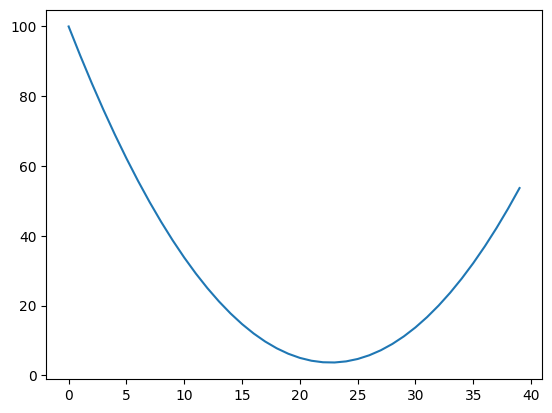

In [4]:
xs = np.arange(-5, 5, 0.25) # generates a range of -5 to 5 going up by 0.25.
ys = f(xs) # gets the y value at each point listed above
plt.plot(ys) # plots those y values

In [5]:
h = 0.00000001
x = 2/3
(f(x + h) - f(x))/h

0.0

In [6]:
#Lets get more complex now!
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [7]:
# We would liek to look at the derivative of d with respect to a,b,c and think about what it tells us. So, we are just looking at the derivative of a function with multiple inputs. Here for example we see what happens to the derivative with respect to a.
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a+=h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)
#intuitively we can tell from some quick mental math that because a is a bit more, d2 is slightly less than d1 and thus the slope is negative


d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [8]:
# Part 5: Starting the core value object of micrograd and its visualization

In [138]:
class Value: # Added comments to understand this Python clearly. This line creates a class.

    def __init__(self, value, _children=(), _op="", label=''): # As evident, Python is much like Java - it is object-oriented. Self in python is like this in java. this init funciton is like a java constructor. thE CONSTRUCTOR IS THE CODE THAT ALLOWS FOR AN OBJECT TO BE CREATED - SO IT IS WHAT RUNS WHEN YOU ATTEMPT OT CREATE AN OBJECT.
        self.value = value
        self._prev = set(_children) # created as a tuple but becomes a set for effeciency. notice that in python you can create fields dynamically - so do not need to declare _prev as a feidl in the top init line.
        self._op = _op 
        self.label = label
        self.grad = 0.0
        
    # When ._prev is called, it will automatically give a set {} where the two children are formatted as according to __repr__.
# children is a pointer, and is by default an empty tuple.
    
    # Whenever an object is created, Python runs "init" to set what is IN IT!

    def __repr__(self): # This function controls 
        return f"Value(data={self.value})" # The f lets you insert variables or expressions right into the string - so your returning a strign where you inserted some variables into the string.

# This method is needed because when a class is created, this method tells Python how the object should appear as text.

    def __add__(self, other): # Must use the exact special name of __add__ and __mult__ to tell the python how operations work for this class.
        out = Value(self.value + other.value, (self, other), '+')
        return out
        
# Note that the methods with __ in their names are called dunder methods - they run automatically in particular situations, and __add__ adn _mul__ are needed for well adding and multiplying.
    
    def __mul__(self, other):
        out = Value(self.value * other.value, (self, other), '*')
        return out

# THIS IS HYPERBOLIC TAN, NOT NORMAL TAN!
    def tanh(self): # self is the value object upon which tan was called and there is no 'other' because tan needs just one input.
        x = self.value # this retreives that value objects memory - without this the object is a collection of fields but herwe we just want its value to operate on.
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1) # we use that value in the formula for tan, obtained from quick search if not memorised
        out = Value(t, (self, ), 'tanh') # the arguments match cuz t is the value, (self, ) is the child node stored as a tuple, and 'tanh' the op. Label was not provided so as per the constructor is left as ''.
        # As for self, when creating an value object such as here using =, the LS is the self implicitly provided and you do not provide it explicitly inside the Value() thing.
        return out
        # Now keep in mind just as we defined tan here to use in neural net you can use any function arbitrarily complex, AS LONG AS YOU ARE ABLE TO KNOW ITS DERIVATIVE FOR THE GRADIENT.

# So we now know whenever we call an arithmetic method the value, the children, and the operation.

a = Value(2.0, label = 'a') # Doing this declares a for example a Value object and the Value functions (methods really) apply to it.
b = Value(-3.0, label = 'b') # So this would run the "constructor" and create an object "b" of class Valye and do b.value = -3.0. self refers to b and the number inside value is value.
c = Value(10.0, label = 'c')
e = a*b; e.label = 'e'
d  = e+c; d.label = 'd'
f = Value(-2.0, label = 'f')
L = d * f; L.label = 'L'


# This is roughly equivalent to (a.__mult__(b)).__add__(c) because when doing arithmetic inside a class python always tries calling __add_ and __mult__ and does whatever you defined these operations to be.
# Note that d is the child here - the Value object created using the new value objects.

# imp: So all this was just creating a class, defining the objects in it, how they will be represented, how arithmetic work son them - and whenever we used arithmetic we wanted to know the value, children and operation that created that value. 

In [10]:
# The above, as explained in the imp note, allows us to take large complex mathematical expressions and break them down so that e understand its elementary parts and can visualize them in a forward pass.

In [11]:
# Back propagation is starting at the end of the forward pass and reverse and calculate the gradient along all the intermediate values, computing the derivative of the end node with respect to all the nodes that come before it. 

In [12]:
%pip install graphviz


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [51]:
from graphviz import Digraph


def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)

            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root, format="svg", rankdir="LR"):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom) | LR (left to right)
    """

    assert rankdir in ["LR", "TB"]

    nodes, edges = trace(root)

    dot = Digraph(
        format=format,
        graph_attr={"rankdir": rankdir}
    )

    # Create the value and operation nodes
    for n in nodes:
        dot.node(
            name=str(id(n)),
            label="{ %s | data %.4f | grad %.4f }"
                  % (n.label, n.value, n.grad),
            shape="record"
        )

        if n._op:
            dot.node(
                name=str(id(n)) + n._op,
                label=n._op
            )

            dot.edge(
                str(id(n)) + n._op,
                str(id(n))
            )

    # Connect each input value to the operation that uses it
    for n1, n2 in edges:
        dot.edge(
            str(id(n1)),
            str(id(n2)) + n2._op
        )

    return dot

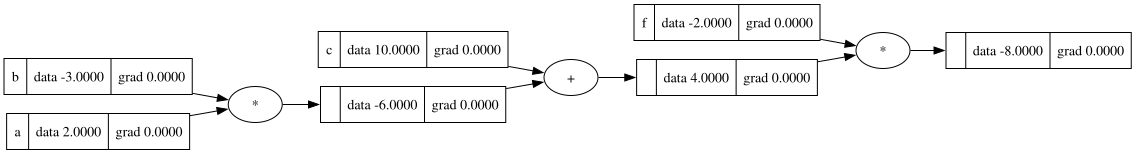

In [119]:
draw_dot(L)

In [104]:
# Part 6: Manual back propogation example 1: simple example.  these are inputted after calculations below.

L.grad = 1.0 
f.grad = d.value
d.grad = f.value
c.grad = d.grad
e.grad = d.grad
a.grad = 6.0
b.grad = -4.0

In [62]:
# Derivative of L with respect to d? Well we have L = d*f, so here we treat f as a constant and d is what we really treat as a 'real' input. This is partial derivatives calculus.

#[F(x+h) - F(x)]/h
#-> [(d+h)f - df]/h   , add h to the input being changed and treat f as a constant.
#-> [df + hf - df]/h
#-> hf/h
#-> f                 , thus the derivative is f.

# symmetrically dL/df = d.


In [87]:
# Now to derive the derivative of L with respect c - for which you first need derivative of d with respect to c.

# dd / dc = ?

# we know d = c + e...
# -> [f(x+h) - f(x)]/h
# -> [((c + h) + e) - (c + e)] / h   , c is the input we are slightly changing so we add h to it.
# -> (c + h + e - c - e)/h
# -> h/h = 1.0                       , by symmetry we also have dd/de = 1.0

# A local plus node derivative is always 1.0 as a rule.

# Great! Now we use: CHAIN RULE.
# Have: dL/dd = -2.0 and dd/dc = 1.0, want dL/dc. So, do dL/dd * dd/dc = -2.0 * 1.0 = -2.0. Notice that dL/dd * dd/dc = dL/dc, so dL/dc = -2.0.

#SO, a plus node just routes the gradient of the parent node back to the current node because when you apply chain rule the plus nodes derivative is 1.0 so the derivative of the node ahead is just routed back. 

In [91]:
# dL/da = (dL/de) * (de/da) - we already hae dL/de = -2.0 from before.
# e = a*b
# de/da = b - can confirm with mental math. Here, the value of b is -3.0.
# Thus, dL/da = (-2.0) * (-3.0) = 6.0
# Similarly dL/db = (-2.0) * (2.0) = -4.0. We got this by doing: dL/db = dL/de * de/db. 

In [114]:
# remember, in Python variables are local!

def lol():

    h = 0.0001
        
    a = Value(2.0, label = 'a') 
    b = Value(-3.0, label = 'b') 
    c = Value(10.0, label = 'c')
    e = a*b; e.label = 'e'
    d  = e+c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L1 = L.value # L1 is first calculation - the "real" unadjusted one, the second will be adjusted for "derivative with respect to ___"

          
    a = Value(2.0, label = 'a') # Getting derivative of L with respect to a.
    b = Value(-3.0, label = 'b') 
    c = Value(10.0, label = 'c')
    e = a*b; e.label = 'e'
    d  = e+c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L' #L now points to the newly calculated point - store it in L2 below!
    L2 = L.value + h # L2 = L would set the pointer L2 to the same value that L points to when in fact we just want to store L2's value in L so we say this instead.
    
    print((L2 - L1)/h)

lol()

0.9999999999976694


In [122]:
# So after understanding this simple maual example, whats an explanation for what back propogation is?
# In backpropogation, you iterate through all nodes one by one and locally apply the chain rule. We recursively apply on the chain rule backwards and get the gradient for each node.

In [121]:
# Part 7: preview of a single optimization setup


# So to adjust L, you move each individual node's value in the direction indicated by that leaf nodes gradient. For example, if I wanted to increase the value of L, I would change the 'leaf nodes' (those whose values I determine and that are not the output of a calculation; here, they are the startings a and b, then c and f) to have values closer to their gradient.
# 1. Create original graph
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
e = a * b
d = e + c
f = Value(-2.0, label="f")
L = d * f

# 2. Manually assign gradients
L.grad = 1.0
d.grad = -2.0
f.grad = 4.0
e.grad = -2.0
c.grad = -2.0
a.grad = 6.0
b.grad = -4.0

# 3. Update only the leaves
a.value += 0.01 * a.grad
b.value += 0.01 * b.grad
c.value += 0.01 * c.grad
f.value += 0.01 * f.grad

# 4. Recalculate output
e = a * b
d = e + c
L = d * f

print(L.value)  # -7.286496

-7.286496


([<matplotlib.lines.Line2D at 0x120d1f850>],
 <function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>)

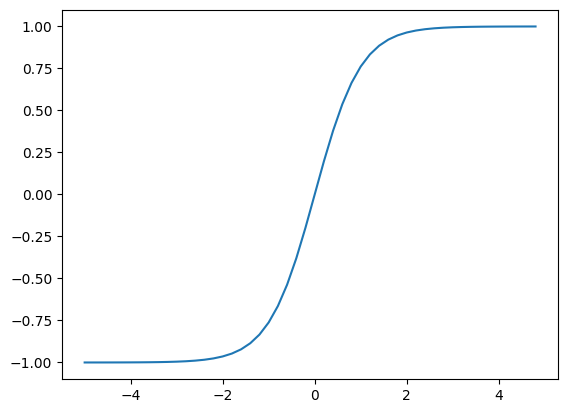

In [126]:
# Part 8: Manual back-propagation example 2: a neuron - we back propagate through them!

#np is used to do mathematical calculations on whole entire arrays.plt, by mat plot lib, lets you plot graphs. 

plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))), plt.plot
# plt.plot(x,y) plots the x and y pair - but here because we used np.arange it creates an array on each side with notation (start, stop, step), and plt.plot plots it out so you see it.

# As you will notice, in the basic mathematical structure of a neuron we will use tan(h) as the squashign function so that big positive or really small negative numbers are nicely bound by 1 and -1. 


In [144]:
# inputs x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weights w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

# bias of the neuron
b = Value(6.88137358701955432, label="b")

# x1*w1 + x2*w2 + b. 
x1w1 = x1 * w1
x1w1.label = "x1*w1"

x2w2 = x2 * w2
x2w2.label = "x2*w2"

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = "x1*w1 + x2*w2"

n = x1w1x2w2 + b # basically we use the dot product wherewe have (x1, x2, ..) and (w1, w2, ...) and then add b to it. thats what the calculations are doing.
n.label = "n"

o = n.tanh()
o.label = "o"


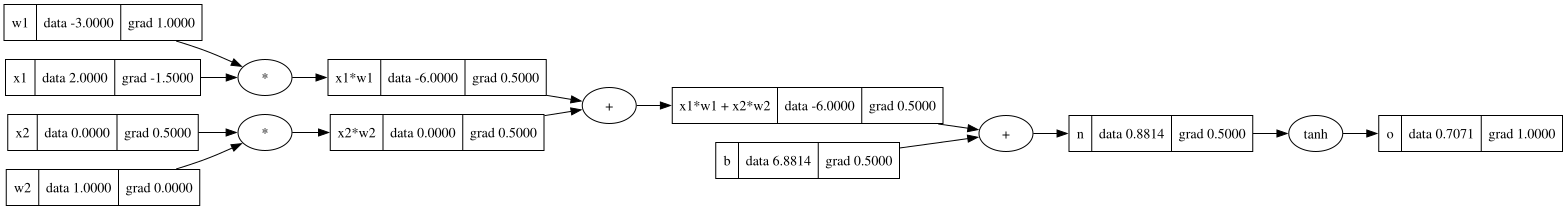

In [159]:
draw_dot(o)

In [160]:
o.grad = 1.0 # base case, always 1.0.
# Now to find the the derivative of o with respect to n.
# We know o = tanh(n), and want do/dn, and know derivative of tanh is 1 - tanh(x)^2.
# thus, do/dn = 1 - tanh(x)^2 = 1 - tanh(n)^2 = 1 - o^2.
n.grad = 1 - o.value**2

# Next we want the gradient of the two plus sign of the nodes left of the one we just got - and since those are a plus those are just a 'bridge' for the gradient to pass backwards.
x1w1x2w2.grad = 0.5
b.grad = 0.5

x1w1.grad = 0.5
x2w2.grad = 0.5

# Now for the gradient of the left-most nodes, we simply use the followjgng trick: each noes gradient is the sibling nodes value multiplied by the gradient of the child (right-er) node.

w1.grad = x1.value * x1w1.grad
x1.grad = w1.value * x1w1.grad

x2.grad = w2.value * x2w2.grad
w2.grad = x2.value * x2w2.grad

# And ALWAYS REMEMBER: the derivative, or gradient, is what we call the mechanism that affects the output. (REFINE DEF)

